In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

In [ ]:
df = pd.read_excel('Absenteeism_at_work.xls')

In [ ]:
df.head()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
0,11,26,7,3,1,289,36,13,33,97,0,1,2,1,0,1,90,172,30,4
1,36,0,7,3,1,118,13,18,50,97,1,1,1,1,0,0,98,178,31,0
2,3,23,7,4,1,179,51,18,38,97,0,1,0,1,0,0,89,170,31,2
3,7,7,7,5,1,279,5,14,39,97,0,1,2,1,1,0,68,168,24,4
4,11,23,7,5,1,289,36,13,33,97,0,1,2,1,0,1,90,172,30,2


In [ ]:
df.describe()

,ID,Reason for absence,Month of absence,Day of the week,Seasons,Transportation expense,Distance from Residence to Work,Service time,Age,Hit target,Disciplinary failure,Education,Son,Social drinker,Social smoker,Pet,Weight,Height,Body mass index,Absenteeism time in hours
count,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000,740.000000
mean,18.017568,19.216216,6.324324,3.914865,2.544595,221.329730,29.631081,12.554054,36.450000,94.587838,0.054054,1.291892,1.018919,0.567568,0.072973,0.745946,79.035135,172.114865,26.677027,6.924324
std,11.021247,8.433406,3.436287,1.421675,1.111831,66.952223,14.836788,4.384873,6.478772,3.779313,0.226277,0.673238,1.098489,0.495749,0.260268,1.318258,12.883211,6.034995,4.285452,13.330998
min,1.000000,0.000000,0.000000,2.000000,1.000000,118.000000,5.000000,1.000000,27.000000,81.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,56.000000,163.000000,19.000000,0.000000
25%,9.000000,13.000000,3.000000,3.000000,2.000000,179.000000,16.000000,9.000000,31.000000,93.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,69.000000,169.000000,24.000000,2.000000
50%,18.000000,23.000000,6.000000,4.000000,3.000000,225.000000,26.000000,13.000000,37.000000,95.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,83.000000,170.000000,25.000000,3.000000
75%,28.000000,26.000000,9.000000,5.000000,4.000000,260.000000,50.000000,16.000000,40.000000,97.000000,0.000000,1.000000,2.000000,1.000000,0.000000,1.000000,89.000000,172.000000,31.000000,8.000000
max,36.000000,28.000000,12.000000,6.000000,4.000000,388.000000,52.000000,29.000000,58.000000,100.000000,1.000000,4.000000,4.000000,1.000000,1.000000,8.000000,108.000000,196.000000,38.000000,120.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   ID                               740 non-null    int64
 1   Reason for absence               740 non-null    int64
 2   Month of absence                 740 non-null    int64
 3   Day of the week                  740 non-null    int64
 4   Seasons                          740 non-null    int64
 5   Transportation expense           740 non-null    int64
 6   Distance from Residence to Work  740 non-null    int64
 7   Service time                     740 non-null    int64
 8   Age                              740 non-null    int64
 9   Hit target                       740 non-null    int64
 10  Disciplinary failure             740 non-null    int64
 11  Education                        740 non-null    int64
 12  Son                              740 non-null    i

In [ ]:
df = df.drop(['Height', 'ID'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Reason for absence               740 non-null    int64
 1   Month of absence                 740 non-null    int64
 2   Day of the week                  740 non-null    int64
 3   Seasons                          740 non-null    int64
 4   Transportation expense           740 non-null    int64
 5   Distance from Residence to Work  740 non-null    int64
 6   Service time                     740 non-null    int64
 7   Age                              740 non-null    int64
 8   Hit target                       740 non-null    int64
 9   Disciplinary failure             740 non-null    int64
 10  Education                        740 non-null    int64
 11  Son                              740 non-null    int64
 12  Social drinker                   740 non-null    i

In [ ]:
df.isnull().sum().max()

0

In [ ]:
X = df.values
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

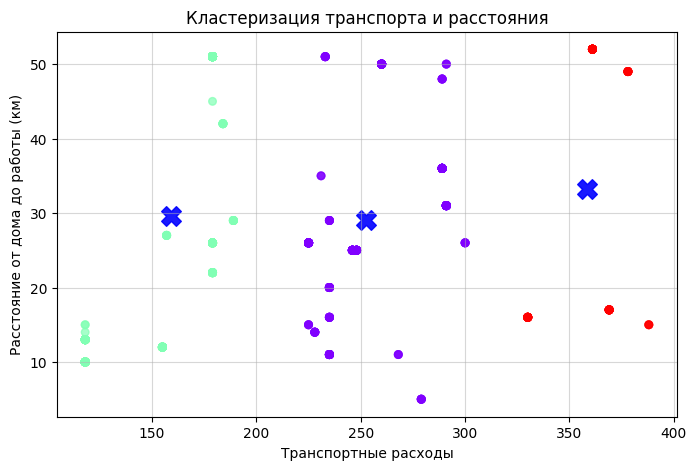

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 4], X[:, 5], c=labels, cmap='rainbow', s=30, alpha=0.7)
plt.scatter(centers[:, 4], centers[:, 5], c='blue', marker='X', s=200, alpha=0.9)
plt.xlabel('Транспортные расходы')
plt.ylabel('Расстояние от дома до работы (км)')
plt.title('Кластеризация транспорта и расстояния')
plt.grid(True, alpha=0.5)

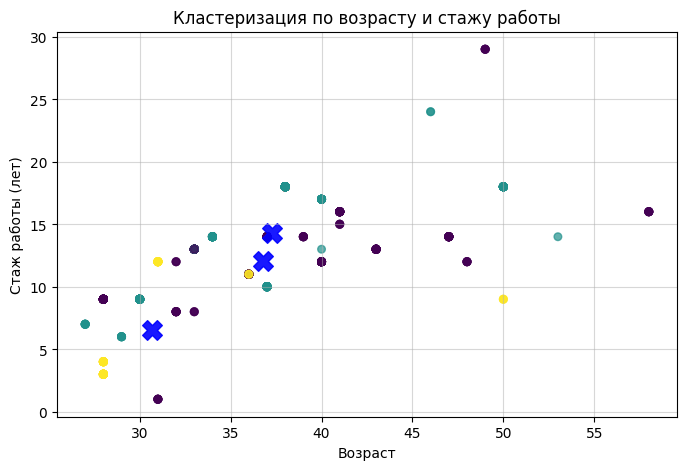

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 7], X[:, 6], c=labels, cmap='viridis', s=30, alpha=0.7)
plt.scatter(centers[:, 7], centers[:, 6], c='blue', marker='X', s=200, alpha=0.9)
plt.xlabel('Возраст')
plt.ylabel('Стаж работы (лет)')
plt.title('Кластеризация по возрасту и стажу работы')
plt.grid(True, alpha=0.5)
plt.show()

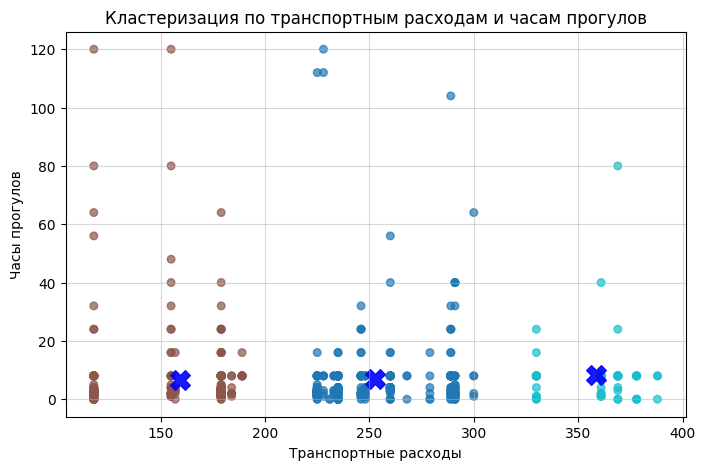

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 4], X[:, 17], c=labels, cmap='tab10', s=30, alpha=0.7)
plt.scatter(centers[:, 4], centers[:, 17], c='blue', marker='X', s=200, alpha=0.9)
plt.xlabel('Транспортные расходы')
plt.ylabel('Часы прогулов')
plt.title('Кластеризация по транспортным расходам и часам прогулов')
plt.grid(True, alpha=0.5)
plt.show()

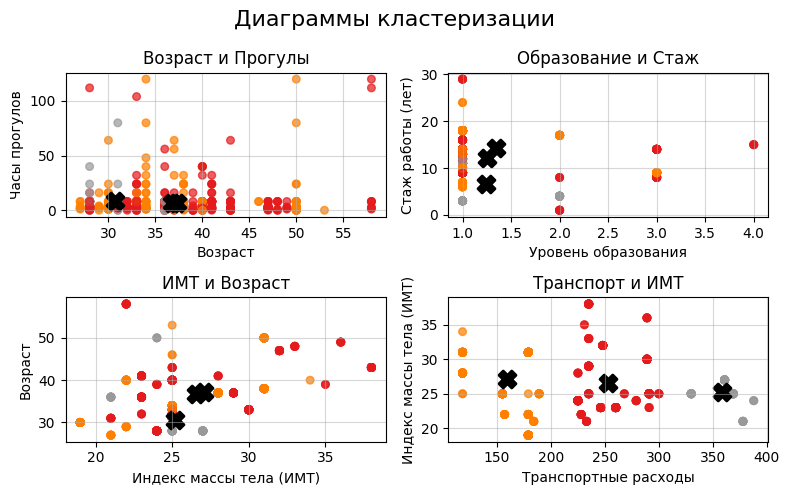

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8,5))
fig.suptitle('Диаграммы кластеризации', fontsize=16)

axes[0, 0].scatter(X[:, 7], X[:, 17], c=labels, cmap='Set1', s=30, alpha=0.7)
axes[0, 0].scatter(centers[:, 7], centers[:, 17], c='black', marker='X', s=150, linewidth=2)
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Часы прогулов')
axes[0, 0].set_title('Возраст и Прогулы')
axes[0, 0].grid(True, alpha=0.5)

axes[0, 1].scatter(X[:, 10], X[:, 6], c=labels, cmap='Set1', s=30, alpha=0.7)
axes[0, 1].scatter(centers[:, 10], centers[:, 6], c='black', marker='X', s=150, linewidth=2)
axes[0, 1].set_xlabel('Уровень образования')
axes[0, 1].set_ylabel('Стаж работы (лет)')
axes[0, 1].set_title('Образование и Стаж')
axes[0, 1].grid(True, alpha=0.5)

axes[1, 0].scatter(X[:, 16], X[:, 7], c=labels, cmap='Set1', s=30, alpha=0.7)
axes[1, 0].scatter(centers[:, 16], centers[:, 7], c='black', marker='X', s=150, linewidth=2)
axes[1, 0].set_xlabel('Индекс массы тела (ИМТ)')
axes[1, 0].set_ylabel('Возраст')
axes[1, 0].set_title('ИМТ и Возраст')
axes[1, 0].grid(True,alpha=0.5)

axes[1, 1].scatter(X[:, 4], X[:, 16], c=labels, cmap='Set1', s=30, alpha=0.7)
axes[1, 1].scatter(centers[:, 4], centers[:, 16], c='black', marker='X', s=150, linewidth=2)
axes[1, 1].set_xlabel('Транспортные расходы')
axes[1, 1].set_ylabel('Индекс массы тела (ИМТ)')
axes[1, 1].set_title('Транспорт и ИМТ')
axes[1, 1].grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

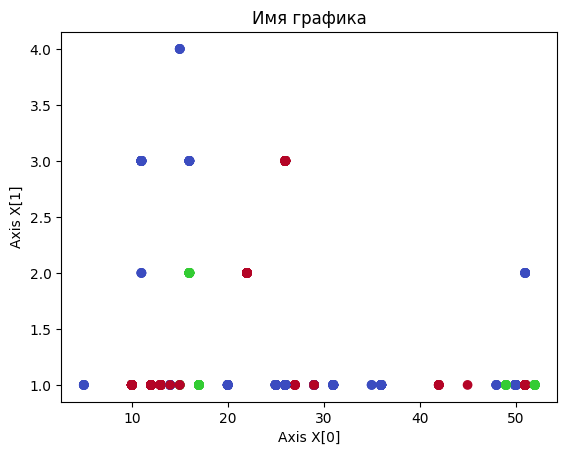

In [ ]:
cluster_colors = ['#3b4cc0', '#b40426', '#33cc33']
colors = [cluster_colors[label] for label in labels]
plt.scatter(X[:, 5], X[:, 10], c=colors, marker='o', picker=True) #исправила ошибку
plt.title('Имя графика')
plt.xlabel('Axis X[0]')
plt.ylabel('Axis X[1]')
plt.show()

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_reduced_tsne = tsne.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_reduced_pca = pca.fit_transform(X)

In [ ]:
import seaborn as sns
import matplotlib.patches as mpatches

In [ ]:
y = kmeans.fit_predict(X)

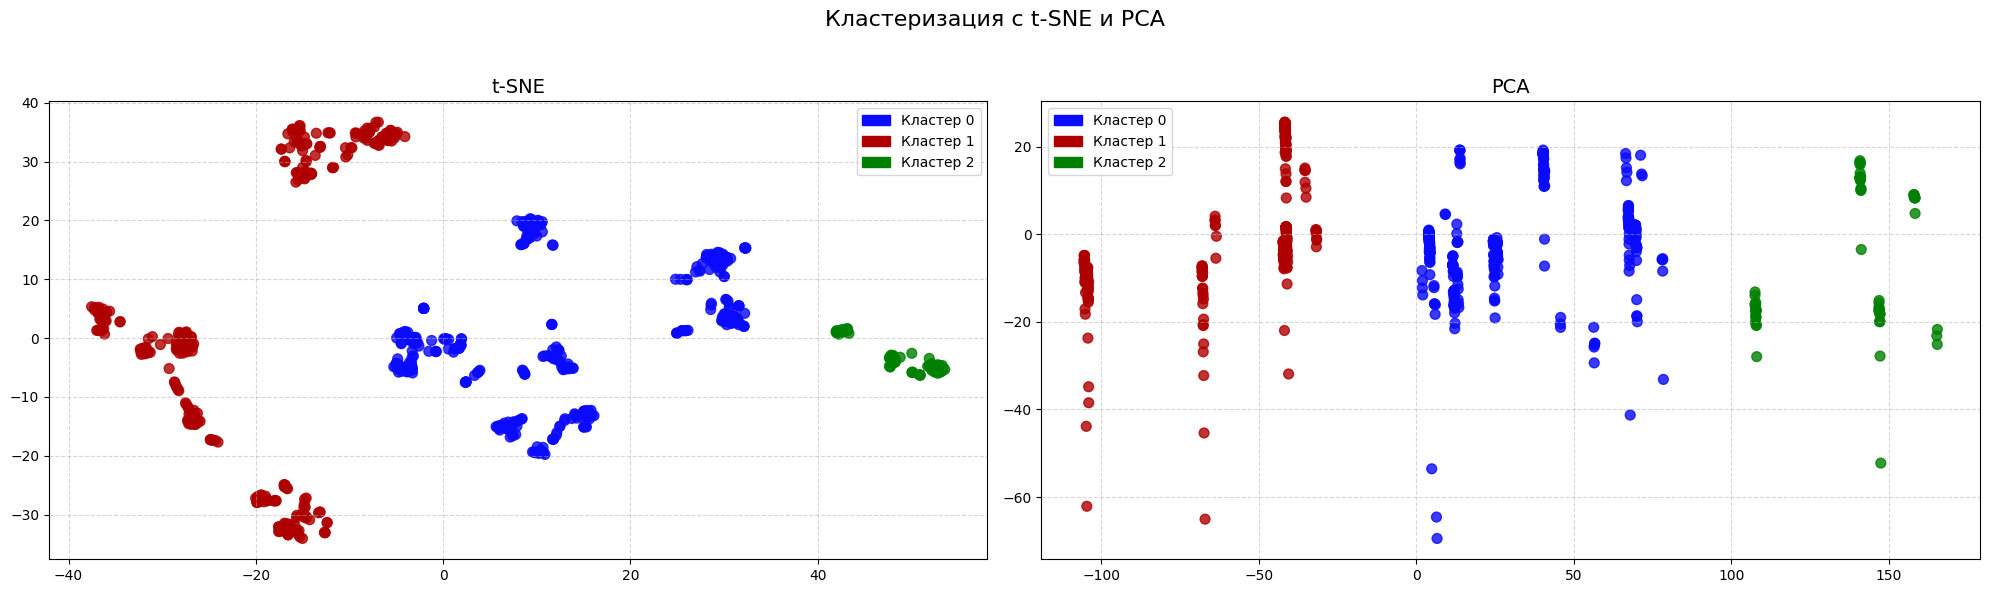

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
f.suptitle('Кластеризация с t-SNE и PCA', fontsize=16)

labels = ['Кластер 0', 'Кластер 1', 'Кластер 2']
color_map = ['#0A0AFF', '#AF0000', '#008000']
point_colors = [color_map[label] for label in y]

scatter1 = ax1.scatter(X_reduced_tsne[:, 0], X_reduced_tsne[:, 1], c=point_colors, s=50, alpha=0.8)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.5)

patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(3)]
ax1.legend(handles=patches)

scatter2 = ax2.scatter(X_reduced_pca[:, 0], X_reduced_pca[:, 1], c=point_colors, s=50, alpha=0.8)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(handles=patches)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=10, min_samples=7).fit(df)
labels5 = db.labels_

n_clusters_ = len(set(labels5)) - (1 if -1 in labels5 else 0)
n_noise_ = list(labels5).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 18
Estimated number of noise points: 184


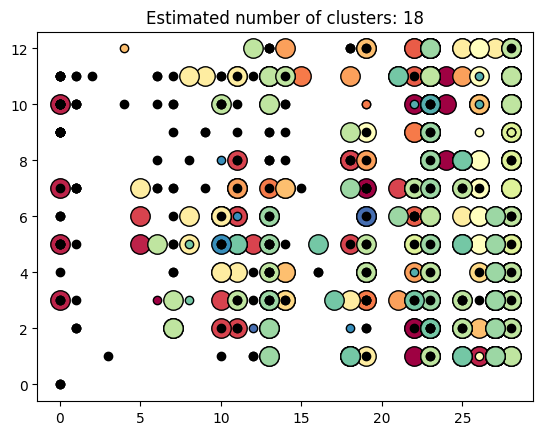

In [ ]:
unique_labels = set(labels5)
core_samples_mask = np.zeros_like(labels5, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels5 == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy [:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy [:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )
plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()
